#**Тема 1. Моделирование геометрической вероятности**
Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.

## Условие задачи

На плоскость, расчерченную сеткой квадратов со стороной $a$, наудачу бросают монету радиуса $r < \dfrac{a}{2}$. Найти вероятность того, что монета не пересечёт ни одной из сторон квадрата. Предполагается, что вероятность попадания точки в плоскую фигуру пропорциональна площади этой фигуры и не зависит от её расположения.

Для расчётов возьмём $a = 4$, $r = 1$.


Пусть событие $A$ - монета не пересекла ни одну из сторон квадрата.

Чтобы определить вероятность данного события, достаточно рассмотреть одну из клеток сетки квадратов со стороной $a$.

Площадь области, соответствующей всем возможным исходам, будет определяться как $S(\Omega)=a^2$. Положение монетки радиусом $r<\dfrac{a}{2}$ определяется положением её центра. Она будет пересекать хотя бы одну из сторон квадрата, если ее центр находится на расстоянии $<r$ от какой-либо стороны. Следовательно, чтобы не пересекать границы сетки, центру монетки нужно попасть в квадратную область, отстоящую от каждой стороны на $r$, т.е. в квадрат со стороной $(a-2r)$. Таким образом, площадь благоприятных исходов равна $S(A)=(a-2r)^2$.

Тогда, $P(A) = \dfrac{S(A)}{S(\Omega)} = \dfrac{(a-2r)^2}{a^2}$.

Используя ранее выбранные значения $a$ и $r$, получаем:

$P(A) = \dfrac{(4-2)^2}{4^2}=\dfrac{4}{16}=\dfrac{1}{4}=0.25$



Смоделируем процесс падения монетки на расчерченную сеткой квадратов плоскость:

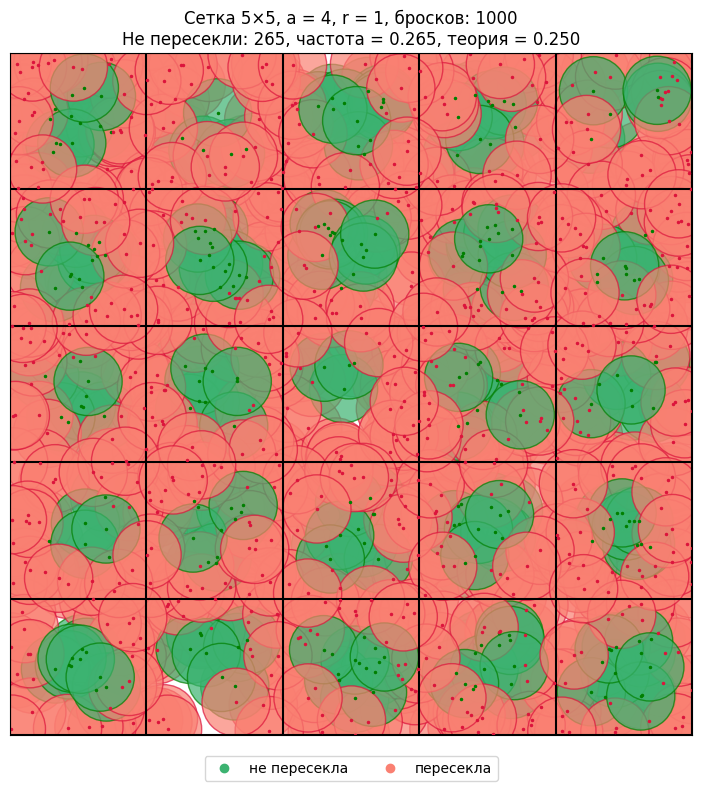

Всего бросков:            1000
Не пересекли стороны:     265
Частота N_A / N:          0.2650
Теоретическая вероятность: (a-2r)²/a² = 0.2500


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


a = 4          # сторона квадрата сетки
r = 1          # радиус монеты
rows = 5       # количество квадратиков по вертикали
cols = rows    # количество квадратиков по горизонтали
n_throws = 1000  # сколько раз бросить монету

assert r < a / 2, 'Радиус монеты должен быть меньше a/2'

width, height = cols * a, rows * a

# случайные центры монет на всей поверхности
x = np.random.uniform(0, width, n_throws)
y = np.random.uniform(0, height, n_throws)

# положение центра внутри своей клетки
dx, dy = x % a, y % a

# монета не пересекает стороны, если центр дальше r от каждой стороны клетки
not_cross = (dx > r) & (dx < a - r) & (dy > r) & (dy < a - r)

n_A = not_cross.sum()
P_theory = (a - 2 * r) ** 2 / a ** 2
P_sim = n_A / n_throws

fig, ax = plt.subplots(figsize=(cols * 1.6, rows * 1.6))

# сетка квадратов
for i in range(cols + 1):
    ax.axvline(i * a, color='black', lw=1.5)
for j in range(rows + 1):
    ax.axhline(j * a, color='black', lw=1.5)

# монеты
for xi, yi, ok in zip(x, y, not_cross):
    color = 'mediumseagreen' if ok else 'salmon'
    edge = 'green' if ok else 'crimson'
    ax.add_patch(Circle((xi, yi), r, facecolor=color, edgecolor=edge, alpha=0.7))
    ax.plot(xi, yi, '.', color=edge, ms=3)

ax.set_xlim(0, width)
ax.set_ylim(0, height)
ax.set_aspect('equal')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'Сетка {rows}×{cols}, a = {a}, r = {r}, бросков: {n_throws}\n'
             f'Не пересекли: {n_A}, частота = {P_sim:.3f}, теория = {P_theory:.3f}')

ax.plot([], [], 'o', color='mediumseagreen', label='не пересекла')
ax.plot([], [], 'o', color='salmon', label='пересекла')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2)

plt.tight_layout()
plt.show()

print(f'Всего бросков:            {n_throws}')
print(f'Не пересекли стороны:     {n_A}')
print(f'Частота N_A / N:          {P_sim:.4f}')
print(f'Теоретическая вероятность: (a-2r)²/a² = {P_theory:.4f}')